# 05 - Explainability
Which features push a customer toward default? Global view (coefficients) and local view (SHAP for one customer).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))   # so we can import from src/

import joblib
import pandas as pd
import matplotlib.pyplot as plt
from src import config
from src.data_preprocessing import load_processed_data

model = joblib.load(config.MODEL_PATH)
X_train, X_test, y_train, y_test = load_processed_data()
print("Model loaded:", type(model).__name__)

Model loaded: LogisticRegression


### Global view: top risk drivers (logistic regression coefficients)

max_repayment_delay    0.172634
PAY_0                  0.137814
avg_repayment_delay    0.111844
PAY_2                  0.109218
PAY_3                  0.096016
PAY_4                  0.089480
PAY_5                  0.080126
PAY_6                  0.073992
avg_bill_amt           0.064488
avg_payment_amt        0.060504
dtype: float64


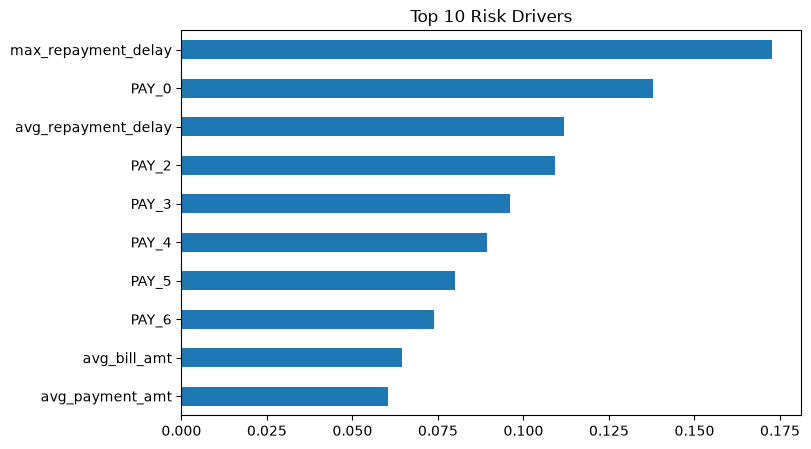

In [2]:
importance = pd.Series(model.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False)
print(importance.head(10))

importance.head(10).sort_values().plot(kind="barh", figsize=(8, 5), title="Top 10 Risk Drivers")
plt.show()

### Local view: explain one customer with SHAP

C:\Users\Ananya\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Background dataset has 24000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=24000 when initializing the masker.


Default Probability: 0.329
Decision: Medium Risk - Manual Review


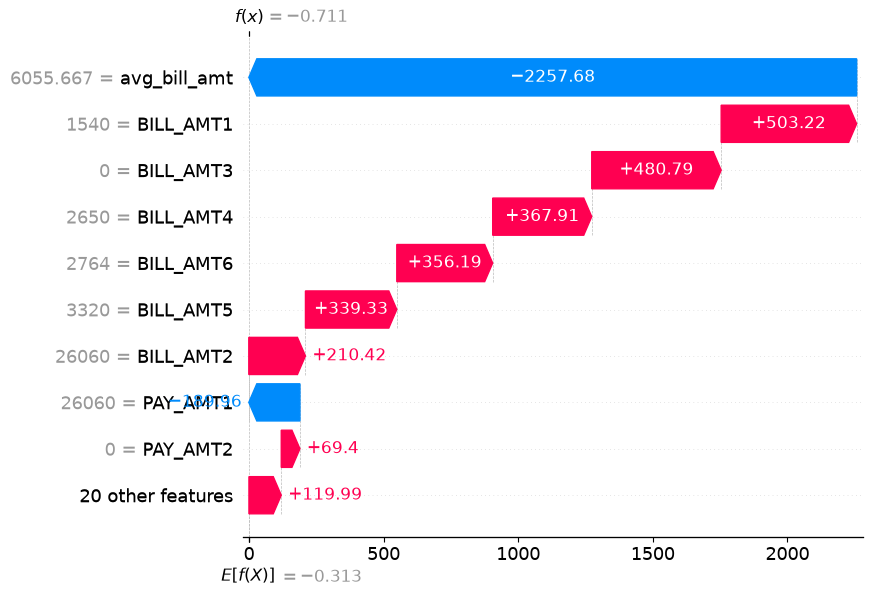

In [3]:
import shap

sample = X_test.iloc[[0]]
proba = model.predict_proba(sample)[0][1]
print("Default Probability:", round(proba, 3))
print("Decision:", config.risk_band(proba))

explainer = shap.Explainer(model, X_train)
shap_values = explainer(sample)
shap.plots.waterfall(shap_values[0])

### Confusion matrix and headline metrics (threshold 0.5)

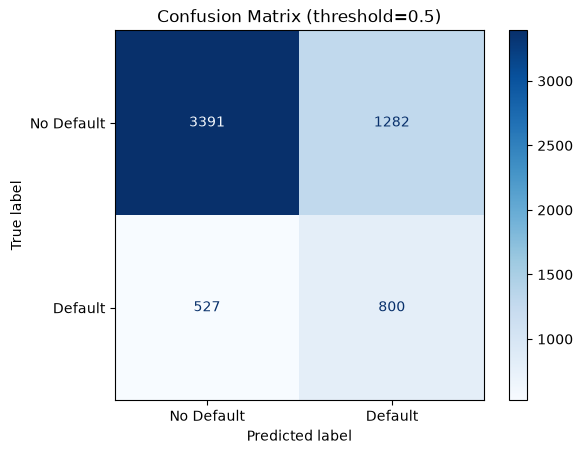

Accuracy : 0.699
Precision: 0.384
Recall   : 0.603
ROC-AUC  : 0.701


In [4]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score, roc_auc_score)

default_probs = model.predict_proba(X_test)[:, 1]
threshold = 0.5
y_pred = (default_probs >= threshold).astype(int)

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=["No Default", "Default"]).plot(cmap="Blues")
plt.title(f"Confusion Matrix (threshold={threshold})")
plt.show()

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, default_probs):.3f}")

### Decisions for the first 5 test customers
Uses the same thresholds as notebook 04 (from `src/config.py`).

In [5]:
for i in range(5):
    p = default_probs[i]
    print(f"Customer {i+1}: Probability={p:.3f}, Decision={config.risk_band(p)}")

Customer 1: Probability=0.329, Decision=Medium Risk - Manual Review
Customer 2: Probability=0.224, Decision=Low Risk - Approve
Customer 3: Probability=0.471, Decision=Medium Risk - Manual Review
Customer 4: Probability=0.258, Decision=Low Risk - Approve
Customer 5: Probability=0.090, Decision=Low Risk - Approve
